In [ ]:
#This code calculates the accessibility of settlements to amenities in a rural municipality.
#I. Data needed
#The user provides :
#- the centres of settlements in .shp,
#- the points of interest (services) in .shp,
#- the gtfs file of the bus routes for the area of interest.

#The boundaries of the settlements are obtained automatically by OSM,
#The road network is automatically downloaded from the OSM after the user enters the coordinates of a polygonal area of interest.#

#II. Accessibility calculation
#Next, the accessibility of settlements to points of interest (amenities) is calculated.

# **CONNECION WITH GOOGLE DRIVE**

# **CONNECION WITH GOOGLE DRIVE**

In [1]:
#Connect with Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **DOWNLOAD AND IMPORT LIBRARIES**

In [2]:
#Download Libraries
!pip install geopandas
!pip install networkx
!pip install osmnx
!pip install geopandas partridge shapely folium
!pip install geopandas transliterate
!pip install partridge pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.5 MB/s eta 0:00:00


In [3]:
#Import Libraries
import geopandas as gpd
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, Polygon
import pandas as pd
import partridge as ptg
import os
from shapely.geometry import Point, LineString
from transliterate import translit
import matplotlib.pyplot as plt
import numpy as np
import itertools

# **READ CITY CENTERS FROM GOOGLE DRIVE**

In [4]:
# Load the shapefile with city centers
city_centers_init = gpd.read_file('/content/drive/My Drive/oikismoi_amari.shp')


In [5]:
# Sort the city_centers based on names of cities
city_centers = city_centers_init.sort_values(by="name_en", ascending=True)

# Print city_centers
print(city_centers)

    OBJECTID        LAT        LON     KALCODE          OIKISMOS  \
22      4742  35.252129  24.632665  7303010101    Αγία Φωτεινή,η   
1       4634  35.152995  24.712253  7303020201  Αγία Παρασκευή,η   
5       4643  35.169611  24.706982  7303020301   ’γιος Ιωάννης,ο   
15      4706  35.223784  24.649481  7303010201        Αμάριον,το   
6       4651  35.183985  24.659985  7303010301      ’νω Μέρος,το   
2       4635  35.154552  24.733992  7303020401      Αποδούλου,το   
21      4741  35.252868  24.626187  7303010102      Απόστολοι,οι   
30      5415  35.149158  24.772941  7303020802        ’ρδακτος,ο   
35      5459  35.172600  24.674529  7303010303      Χωρδάκιον,το   
34      5458  35.193844  24.651477  7303010302        Δρυγιαί,αι   
14      4699  35.217434  24.614231  7303010801         Ελέναι,αι   
11      4687  35.208796  24.710363  7303020101      Φουρφουράς,ο   
32      5456  35.247822  24.637123  7303010103           Γέννα,η   
12      4691  35.210109  24.604165  7303010701  

In [6]:
# Convert greek characters to english
# Define the column with Greek characters, e.g., 'Greek_Column'
greek_column = 'TOP_KOIN'

# Transliterate Greek characters to English in the specified column
city_centers[greek_column] = city_centers[greek_column].apply(lambda x: translit(x, 'el', reversed=True) if isinstance(x, str) else x)

# **DOWNLOAD ROAD NETWORK FROM OSM**

In [7]:
# Define your area of interest as a polygon using coordinates (longitude, latitude)
# Example: a rough square polygon
area_polygon = Polygon([
    (24.5430, 35.3081),
    (24.5430, 35.0982),
    (24.8142, 35.0982),
    (24.8142, 35.3081)
])

In [8]:
# Download the road network for the area inside the polygon
G = ox.graph_from_polygon(area_polygon, network_type='all')

In [9]:
# Convert the road network to a GeoDataFrame for nodes and edges
nodes, edges = ox.graph_to_gdfs(G)

# Save the edges (road network) to a shapefile
edges.to_file('road_network.shp')

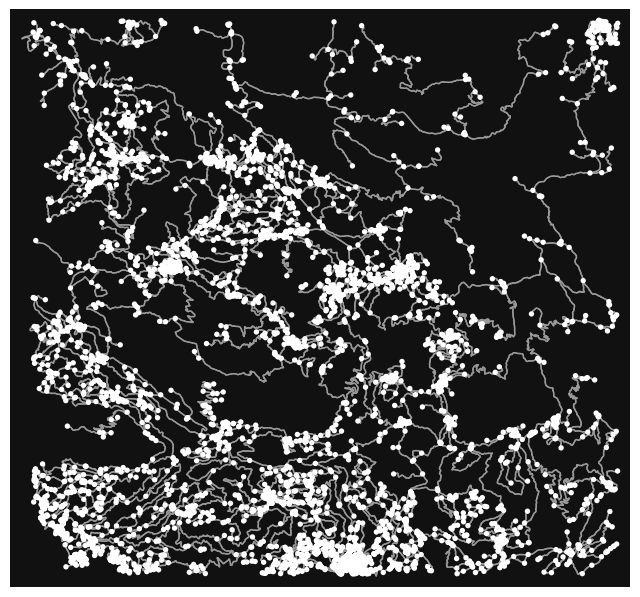

In [10]:
# Plot the graph (road network)
ox.plot_graph(G)
plt.show()

# **SET SPEED AND DISTANCE**

In [11]:
# Set walking speed (meters per minute)
walking_speed = 80  # average walking speed: 80 meters/minute
time_limit = 15  # walking time in minutes
distance_limit = walking_speed * time_limit  # 15-minute walk = 1200 meters

In [12]:
# Get the CRS of the road network and project the city centers to match it
nodes, edges = ox.graph_to_gdfs(G)
road_network_crs = nodes.crs  # Get the CRS of the nodes GeoDataFrame
city_centers = city_centers.to_crs(road_network_crs)

In [13]:
print(city_centers.crs)

epsg:4326


# **CREATE ISOCHRONES AROUND CITY CENTERS**

<ipython-input-14-67dc15a2d04e>:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  isochrone_polygon = gpd.GeoSeries(node_points).unary_union.convex_hull
<ipython-input-14-67dc15a2d04e>:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  isochrone_polygon = gpd.GeoSeries(node_points).unary_union.convex_hull
<ipython-input-14-67dc15a2d04e>:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  isochrone_polygon = gpd.GeoSeries(node_points).unary_union.convex_hull
<ipython-input-14-67dc15a2d04e>:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  isochrone_polygon = gpd.GeoSeries(node_points).unary_union.convex_hull
<ipython-input-14-67dc15a2d04e>:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  isochrone_polygon = g

<Axes: >

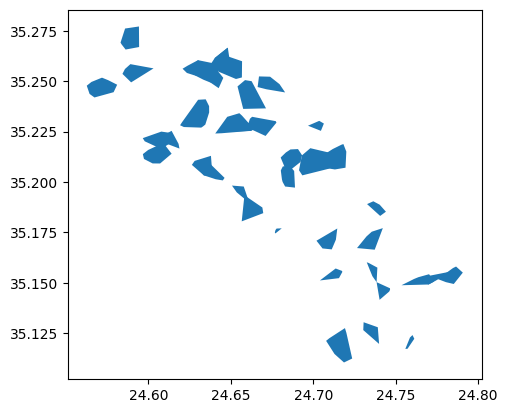

In [14]:
# Function to calculate isochrone from each city center point
isochrones = []

for idx, city in city_centers.iterrows():
    # Get the city center point as (latitude, longitude)
    center_point = (city.geometry.y, city.geometry.x)

    # Find the nearest road network node to the city center
    nearest_node = ox.distance.nearest_nodes(G, X=center_point[1], Y=center_point[0])

    # Create subgraph of all reachable nodes within the walking distance (1200 meters)
    subgraph = nx.ego_graph(G, nearest_node, radius=distance_limit, distance='length')

    # Get node coordinates (x, y) for the reachable nodes
    node_points = [Point(data['x'], data['y']) for node, data in subgraph.nodes(data=True)]

    if node_points:
        # Create a GeoSeries of node points and compute the convex hull to get a polygon
        isochrone_polygon = gpd.GeoSeries(node_points).unary_union.convex_hull

        # Ensure that the geometry is a Polygon
        if isinstance(isochrone_polygon, Polygon):
            # Append the result as a dictionary with city name and geometry
            isochrones.append({'city': city['name_en'], 'geometry': isochrone_polygon})

# Convert list of isochrones to a GeoDataFrame
isochrones_gdf = gpd.GeoDataFrame(isochrones, crs=city_centers.crs)

# Plot the isochrones
isochrones_gdf.plot()


In [15]:
# Save the isochrones to a shapefile
isochrones_gdf.to_file('15_minute_walking_isochrones.shp')

# **SELECT POI WITHIN ISOCHRONES**

In [16]:
# Load the isochrones polygons and read points of interest from Google Drive
gdf_polygons = gpd.read_file('/content/15_minute_walking_isochrones.shp')
gdf_points = gpd.read_file('/content/drive/My Drive/new_pois_amari.shp')

In [17]:
# Convert to WGS84 (EPSG:4326)
gdf_points_wgs84 = gdf_points.to_crs(epsg=4326)
# Convert to WGS84 (EPSG:4326)
gdf_polygons_wgs84 = gdf_polygons.to_crs(epsg=4326)

In [18]:
# Ensure both layers are in the same CRS
if gdf_polygons.crs != gdf_points.crs:
    gdf_polygons = gdf_polygons.to_crs(gdf_points.crs)

In [19]:
# Save the converted points to a new shapefile
gdf_points_wgs84.to_file('converted_poi_wgs84.shp')

In [20]:
# Find points that are within the polygons
points_within_polygons = gdf_points[gdf_points.geometry.apply(lambda point: any(point.within(polygon) for polygon in gdf_polygons.geometry))]


In [21]:
# Check if there are any points found
if not points_within_polygons.empty:
    print(f"Number of points found: {len(points_within_polygons)}")

    # Save the filtered points that are within polygons to a new shapefile
    points_within_polygons.to_file('points_within_polygons.shp', driver='ESRI Shapefile')

else:
    print("No points were found within the polygons.")

Number of points found: 44


In [22]:
# Load the shapefiles of isochrones polygons
isochrones = gdf_polygons

services = gpd.read_file('/content/points_within_polygons.shp')

In [23]:
# Ensure the CRS matches between both GeoDataFrames
services = services.to_crs(isochrones.crs)

# Check for null values in the village names column
print(isochrones['city'].isnull().sum())  # Adjust 'city' to your column name
print(isochrones['city'].unique())  # To see all unique names, including None

# Fill null values with a placeholder (optional)
isochrones['city'] = isochrones['city'].fillna('Unknown Village')

# Perform the spatial join
joined_data = gpd.sjoin(services, isochrones, predicate='within', how='right')

# Group by village name and count the services
service_counts = (
    joined_data.groupby('city')['Name']  # Replace 'city' with the actual village name column
    .count()
    .reindex(isochrones['city'].unique(), fill_value=0)  # Ensure all villages are included
)


0
['Agia Foteini' 'Agia Paraskevi' 'Agios Ioannis' 'Amari' 'Ano meros'
 'Apodoulou' 'Apostoloi' 'Ardaktos' 'Chordaki' 'Drigies' 'Elenes'
 'Fourfouras' 'Genna' 'Gerakari' 'Kalogeros' 'Kardaki' 'Klisidi'
 'Kouroutes' 'Lampiotes' 'Lochria' 'Mandres' 'Meronas' 'Mesonisia'
 'Monastiraki' 'Moni Asomaton' 'Nithauris' 'Opsigias' 'Pantanassa'
 'Patsos' 'Petrochori' 'Platania' 'Platanos' 'Rizikas' 'Sata' 'Thronos'
 'Vathiaki' 'Vistagi' 'Vizari' 'Voliones' 'Vrises']


In [24]:
# Sort service_counts based on city names
service_counts_sorted = service_counts.sort_index(ascending=True)

print(service_counts_sorted)

city
Agia Foteini      6
Agia Paraskevi    1
Agios Ioannis     1
Amari             1
Ano meros         1
Apodoulou         2
Apostoloi         6
Ardaktos          2
Chordaki          1
Drigies           0
Elenes            0
Fourfouras        7
Genna             2
Gerakari          4
Kalogeros         0
Kardaki           0
Klisidi           1
Kouroutes         2
Lampiotes         2
Lochria           1
Mandres           0
Meronas           3
Mesonisia         0
Monastiraki       0
Moni Asomaton     0
Nithauris         4
Opsigias          1
Pantanassa        1
Patsos            1
Petrochori        1
Platania          1
Platanos          3
Rizikas           0
Sata              0
Thronos           1
Vathiaki          0
Vistagi           1
Vizari            2
Voliones          0
Vrises            0
Name: Name, dtype: int64


In [25]:
# Convert the counts into a DataFrame with village names as columns
services_table = pd.DataFrame([service_counts_sorted.values], columns=service_counts_sorted.index)

# Rename the index to indicate it represents service counts
services_table.index = ['service_count']

# View the final table
print(services_table)

# # Optionally save to CSV or another format
services_table.to_csv('/content/services_table.csv')

# from google.colab import files
# files.download('/content/services_table.csv')

city           Agia Foteini  Agia Paraskevi  Agios Ioannis  Amari  Ano meros  \
service_count             6               1              1      1          1   

city           Apodoulou  Apostoloi  Ardaktos  Chordaki  Drigies  ...  \
service_count          2          6         2         1        0  ...   

city           Platania  Platanos  Rizikas  Sata  Thronos  Vathiaki  Vistagi  \
service_count         1         3        0     0        1         0        1   

city           Vizari  Voliones  Vrises  
service_count       2         0       0  

[1 rows x 40 columns]


# **GTFS FILE**

In [26]:
# Path to your GTFS file
gtfs_path = "/content/drive/My Drive/amari_gtfs.zip"

# Read the GTFS data using partridge
feed = ptg.load_feed(gtfs_path, view=None)

# Access the data as individual pandas DataFrames
routes = feed.routes
trips = feed.trips
stops = feed.stops
stop_times = feed.stop_times
calendar = feed.calendar


In [27]:
# Extract the GTFS tables
trips = feed.trips
stop_times = feed.stop_times
stops = feed.stops
calendar = feed.calendar

# List of stops you're interested in
selected_stops = [
    "Agia Foteini", "Agia Paraskevi", "Agios Ioannis", "Amari", "Ano Meros", "Apodoulou",
    "Apostoloi", "Ardaktos", "Chordaki", "Drigies", "Elenes", "Fourfouras", "Genna",
    "Gerakari", "Kalogeros", "Kardaki", "Klisidi", "Kouroutes", "Lampiotes", "Lochria",
    "Mandres", "Meronas", "Mesonisia", "Monastiraki", "Moni Asomaton", "Nithauris",
    "Opsigias", "Pantanassa", "Patsos", "Petrochori", "Platania", "Platanos", "Rizikas",
    "Sata", "Thronos", "Vathiaki", "Vistagi", "Vizari", "Voliones", "Vrises"
]

In [28]:
# Join stop_times with stops to get stop names
stop_times_with_names = stop_times.merge(stops[['stop_id', 'stop_name']], on='stop_id', how='left')
stop_times_with_names = stop_times_with_names[['trip_id', 'stop_id', 'stop_sequence', 'stop_name']]

# Filter for selected stops
filtered_stop_times = stop_times_with_names[stop_times_with_names['stop_name'].isin(selected_stops)]

# Self-join to get Origin-Destination pairs for each trip
od_pairs = filtered_stop_times.merge(
    filtered_stop_times,
    on='trip_id',
    suffixes=('_origin', '_destination')
)
# Ensure the origin stop comes before the destination stop in sequence
od_pairs = od_pairs[od_pairs['stop_sequence_origin'] < od_pairs['stop_sequence_destination']]

# Join with trips and calendar data to get service information
od_with_service = od_pairs.merge(trips, on='trip_id', how='left').merge(calendar, on='service_id', how='left')

In [29]:
# Summarize weekly trips between the selected stops
od_weekly = od_with_service.groupby(['stop_name_origin', 'stop_name_destination']).agg(
    weekly_trips=pd.NamedAgg(
        column='monday',
        aggfunc=lambda x: x.sum() + od_with_service['tuesday'].sum() +
                          od_with_service['wednesday'].sum() + od_with_service['thursday'].sum() +
                          od_with_service['friday'].sum()
    )
).reset_index()


In [30]:
# Calculate weekly trips by summing the days of the week for each O-D pair
od_with_service['weekly_trips'] = od_with_service[['monday', 'tuesday', 'wednesday', 'thursday', 'friday']].sum(axis=1)
od_weekly = od_with_service.groupby(['stop_name_origin', 'stop_name_destination'], as_index=False)['weekly_trips'].sum()

# Ensure there are no missing values
od_weekly['weekly_trips'] = od_weekly['weekly_trips'].fillna(0)



In [31]:
# Step 1: Create all possible O-D pairs (including self-pairs)
all_od_pairs = pd.DataFrame(itertools.product(selected_stops, selected_stops), columns=['stop_name_origin', 'stop_name_destination'])

In [32]:
# Step 2: Left join the summarized weekly trips to the full set of O-D pairs
od_complete = all_od_pairs.merge(od_weekly, on=['stop_name_origin', 'stop_name_destination'], how='left')
od_complete['weekly_trips'] = od_complete['weekly_trips'].fillna(0)  # Set missing trips to 0

In [33]:
# Step 3: Create a symmetric matrix for each O-D pair

# Merge od_complete with itself to get forward and reverse pairs
od_symmetric = pd.merge(
    od_complete,
    od_complete,
    left_on=["stop_name_origin", "stop_name_destination"],
    right_on=["stop_name_destination", "stop_name_origin"],
    suffixes=('_forward', '_reverse'),
    how='outer'
)

# Fill NaN values in the trip columns with 0 for both directions
od_symmetric['weekly_trips_forward'] = od_symmetric['weekly_trips_forward'].fillna(0)
od_symmetric['weekly_trips_reverse'] = od_symmetric['weekly_trips_reverse'].fillna(0)

# Sum the trips in both directions
od_symmetric['weekly_trips'] = od_symmetric['weekly_trips_forward'] + od_symmetric['weekly_trips_reverse']

# Select the original columns plus the new forward and reverse columns
od_symmetric = od_symmetric[[ 'stop_name_origin_forward', 'stop_name_destination_forward',  'weekly_trips']]

od_symmetric = od_symmetric.rename(columns={
    'stop_name_origin_forward': 'stop_name_origin',
    'stop_name_destination_forward': 'stop_name_destination'
})


In [34]:
# Step 4: Pivot to create the O-D matrix in wide format, ensuring correct row/column order
od_matrix_symmetric = od_symmetric.pivot(index='stop_name_origin', columns='stop_name_destination', values='weekly_trips').fillna(0)
od_matrix_symmetric = od_matrix_symmetric.reindex(index=selected_stops, columns=selected_stops, fill_value=0).reset_index()

In [35]:
# Assuming od_matrix_symmetric has a column 'stop_name_origin' as the first column
# Remove the first column (stop names) and convert the DataFrame to a NumPy matrix
stop_names = od_matrix_symmetric['stop_name_origin']  # Extract the stop names
od_matrix = od_matrix_symmetric.iloc[:, 1:].to_numpy()  # Convert remaining columns to NumPy array

# Set the diagonal elements to 5
np.fill_diagonal(od_matrix, 5)

# Set all values in the matrix that exceed 5 to exactly 5
od_matrix = np.minimum(od_matrix, 5)

# Convert the modified matrix back to a DataFrame, with the stop names as the first column
od_matrix_symmetric = pd.DataFrame(od_matrix, columns=od_matrix_symmetric.columns[1:])
od_matrix_symmetric.insert(0, 'stop_name', stop_names)  # Add stop names as the first column


In [36]:
pd.options.display.max_columns = None
print(od_matrix_symmetric)

stop_name_destination       stop_name  Agia Foteini  Agia Paraskevi  \
0                        Agia Foteini           5.0             0.0   
1                      Agia Paraskevi           0.0             5.0   
2                       Agios Ioannis           0.0             2.0   
3                               Amari           3.0             0.0   
4                           Ano Meros           2.0             2.0   
5                           Apodoulou           3.0             2.0   
6                           Apostoloi           2.0             0.0   
7                            Ardaktos           3.0             0.0   
8                            Chordaki           0.0             2.0   
9                             Drigies           2.0             0.0   
10                             Elenes           4.0             0.0   
11                         Fourfouras           5.0             4.0   
12                              Genna           0.0             0.0   
13    

# **ACCESSIBILITY CALCULATION**

In [ ]:
# Load the land uses CSV file
landuses = service_counts_sorted

# # Transpose the land uses table
#landuses_transposed = landuses.T

# Assuming od_matrix_symmetric is a DataFrame loaded or created previously,
# convert it to a matrix excluding the first column if it contains non-numeric data
freq = od_matrix_symmetric.iloc[:, 1:].values  # Adjust if needed

# Flatten the transposed land uses matrix into a vector
Uses = landuses.values.flatten()

# Calculate the sum-product of freq and Uses
sumproduct = np.dot(freq, Uses)

# Convert sumproduct to a DataFrame
Access_Final = pd.DataFrame(sumproduct, columns=["Accessibility"])

# Display the final accessibility DataFrame
print(Access_Final)

# # Save to CSV if needed
# Access_Final.to_csv('/content/Access_Final.csv', index=False)

    Accessibility
0           183.0
1            63.0
2            63.0
3            61.0
4           105.0
5           145.0
6            62.0
7           103.0
8            63.0
9            44.0
10           65.0
11          173.0
12           10.0
13           73.0
14           37.0
15           65.0
16          133.0
17          145.0
18           45.0
19          101.0
20            0.0
21           71.0
22           65.0
23           58.0
24          133.0
25          145.0
26           61.0
27           47.0
28           47.0
29           99.0
30           63.0
31          105.0
32            0.0
33            0.0
34          133.0
35           99.0
36           41.0
37          161.0
38           22.0
39           44.0


In [ ]:
# Assuming 'df' is your pandas DataFrame
landuses.to_csv('landuses.csv', index=False)  # 'index=False' prevents saving the index as a column

In [ ]:
pd.options.display.max_columns = None
print(landuses)

city
Agia Foteini      6
Agia Paraskevi    1
Agios Ioannis     1
Amari             1
Ano meros         1
Apodoulou         2
Apostoloi         6
Ardaktos          2
Chordaki          1
Drigies           0
Elenes            0
Fourfouras        7
Genna             2
Gerakari          4
Kalogeros         0
Kardaki           0
Klisidi           1
Kouroutes         2
Lampiotes         2
Lochria           1
Mandres           0
Meronas           3
Mesonisia         0
Monastiraki       0
Moni Asomaton     0
Nithauris         4
Opsigias          1
Pantanassa        1
Patsos            1
Petrochori        1
Platania          1
Platanos          3
Rizikas           0
Sata              0
Thronos           1
Vathiaki          0
Vistagi           1
Vizari            2
Voliones          0
Vrises            0
Name: Name, dtype: int64


In [ ]:
# Ensure freq is a 2D array
freq = od_matrix_symmetric.iloc[:, 1:].values  # Exclude the first column if it's non-numeric

# Flatten the transposed land uses matrix into a vector
Uses = landuses.values.flatten()

# Check shape compatibility
print("Shape of freq:", freq.shape)
print("Length of Uses:", Uses.shape)

# Perform the dot product
sumproduct = np.dot(freq, Uses)

# Ensure the result is 2D for creating a DataFrame
sumproduct = sumproduct.reshape(-1, 1)  # Only needed if sumproduct is not 1D

# Convert sumproduct to a DataFrame
Access_Final = pd.DataFrame(sumproduct, columns=["Accessibility"])

# Display the final accessibility DataFrame
print(Access_Final)

Shape of freq: (40, 40)
Length of Uses: (40,)
    Accessibility
0           183.0
1            63.0
2            63.0
3            61.0
4           105.0
5           145.0
6            62.0
7           103.0
8            63.0
9            44.0
10           65.0
11          173.0
12           10.0
13           73.0
14           37.0
15           65.0
16          133.0
17          145.0
18           45.0
19          101.0
20            0.0
21           71.0
22           65.0
23           58.0
24          133.0
25          145.0
26           61.0
27           47.0
28           47.0
29           99.0
30           63.0
31          105.0
32            0.0
33            0.0
34          133.0
35           99.0
36           41.0
37          161.0
38           22.0
39           44.0


In [ ]:
# Check that city_centers is sorted
city_centers_sorted = city_centers.sort_values(by="name_en", ascending=True)

# Create a copy of Access_Final_settl
Access_Final_settl = Access_Final.copy()

# Add pop of city_centers table
Access_Final_settl['pop'] = city_centers_sorted['pop_2021'].values

# Add 'TOP_KOIN' keeping the sorting of names
Access_Final_settl['TOP_KOIN'] = city_centers_sorted['TOP_KOIN'].values

# Print final table
print(Access_Final_settl)


    Accessibility  pop                                TOP_KOIN
0           183.0  105              Topiki Koinotita Apostolon
1            63.0   76       Topiki Koinotita Agias Paraskeuis
2            63.0   94  Topiki Koinotita Agioy Ioannoy Amarioy
3            61.0  165                Topiki Koinotita Amarioy
4           105.0  277             Topiki Koinotita ’no Meroys
5           145.0  214              Topiki Koinotita Apodoyloy
6            62.0  185              Topiki Koinotita Apostolon
7           103.0   27               Topiki Koinotita Lochrias
8            63.0    5             Topiki Koinotita ’no Meroys
9            44.0   23             Topiki Koinotita ’no Meroys
10           65.0   57                 Topiki Koinotita Elenon
11          173.0  509              Topiki Koinotita Foyrfoyra
12           10.0   28              Topiki Koinotita Apostolon
13           73.0  354             Topiki Koinotita Gerakarioy
14           37.0  128              Topiki Koinotita Ka

In [ ]:
#Remove Prefix of community names
Access_Final_settl['TOP_KOIN'] = Access_Final_settl['TOP_KOIN'].str.replace("Topiki Koinotita ", "", regex=False).str.strip()

# Replace "’" with "A"
Access_Final_settl['TOP_KOIN'] = (
    Access_Final_settl['TOP_KOIN']
    .str.replace("Topiki Koinotita ", "", regex=False)  # Αφαίρεση του κειμένου
    .str.replace("’", "A", regex=False)  # Αντικατάσταση του χαρακτήρα
)

# Print new dataframe
print(Access_Final_settl)

    Accessibility  pop               TOP_KOIN
0           183.0  105              Apostolon
1            63.0   76       Agias Paraskeuis
2            63.0   94  Agioy Ioannoy Amarioy
3            61.0  165                Amarioy
4           105.0  277             Ano Meroys
5           145.0  214              Apodoyloy
6            62.0  185              Apostolon
7           103.0   27               Lochrias
8            63.0    5             Ano Meroys
9            44.0   23             Ano Meroys
10           65.0   57                 Elenon
11          173.0  509              Foyrfoyra
12           10.0   28              Apostolon
13           73.0  354             Gerakarioy
14           37.0  128              Kalogeroy
15           65.0   39                 Vruson
16          133.0   25                Thronoy
17          145.0  234              Koyroyton
18           45.0   69               Labioton
19          101.0  215               Lochrias
20            0.0   10            

In [ ]:
# Save Access_oikismoi to CSV
Access_Final_settl.to_csv('/content/Access_Final_settl.csv', index=False)

In [ ]:
# Calculate population-weighted accessibility for each community
community_accessibility = Access_Final_settl.groupby('TOP_KOIN').apply(
    lambda x: pd.Series({
        'total_population': x['pop'].sum(),
        'weighted_accessibility': (x['Accessibility'] * x['pop']).sum() / x['pop'].sum()
    })
).reset_index()

# Add an 'id' column to community_accessibility
community_accessibility['id'] = range(1, len(community_accessibility) + 1)

# Display the results
print(community_accessibility)

                 TOP_KOIN  total_population  weighted_accessibility  id
0        Agias Paraskeuis              76.0               63.000000   1
1   Agioy Ioannoy Amarioy              94.0               63.000000   2
2                 Amarioy             189.0               61.000000   3
3              Ano Meroys             305.0               99.711475   4
4               Apodoyloy             241.0              128.755187   5
5               Apostolon             318.0               97.374214   6
6                  Elenon             169.0               65.000000   7
7               Foyrfoyra             509.0              173.000000   8
8              Gerakarioy             354.0               73.000000   9
9               Kalogeroy             128.0               37.000000  10
10              Koyroyton             234.0              145.000000  11
11               Labioton              69.0               45.000000  12
12               Lochrias             242.0              101.223

<ipython-input-99-729e2d2295e0>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  community_accessibility = Access_Final_settl.groupby('TOP_KOIN').apply(


In [ ]:
# Save Access_oikismoi to CSV
community_accessibility.to_csv('/content/community_accessibility.csv', index=False)